In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [101]:
# load the dataset
df = pd.read_csv('../data/boston_housing.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [103]:
# null check.
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

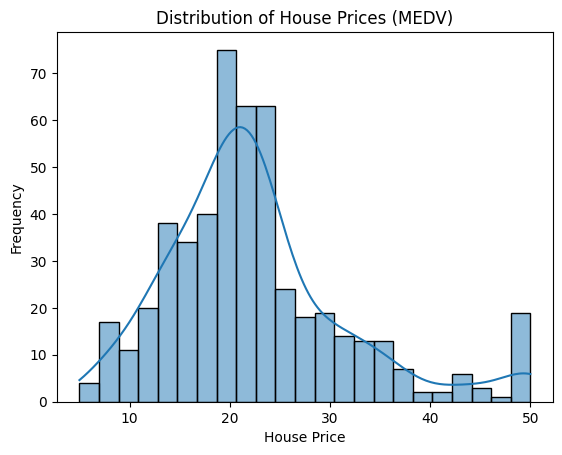

In [106]:
# target variable distribution.

sns.histplot(data=df['MEDV'], kde=True)
plt.title('Distribution of House Prices (MEDV)')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

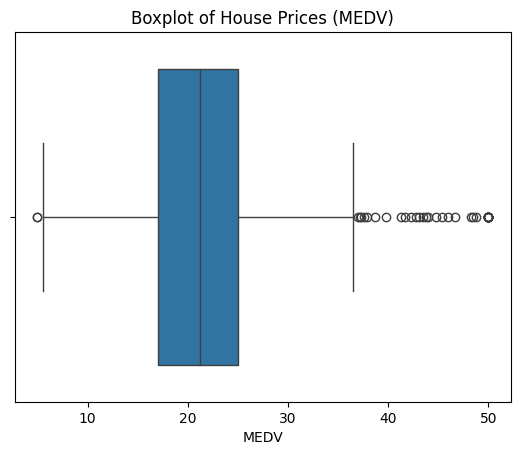

In [108]:
# boxplot of the target variable.

sns.boxplot(x=df['MEDV'])
plt.title('Boxplot of House Prices (MEDV)')
plt.show()

In [109]:
# removing the outliers.

Q1 = df['MEDV'].quantile(0.25)
Q3 = df['MEDV'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['MEDV'] >= lower_bound) & (df['MEDV'] <= upper_bound)]

In [111]:
# split dataset features.
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [112]:
# spit for train and test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
# scale the features.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
# build and compile the neural network.

model = Sequential()

# input-layer + hidden-layer_1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

# hidden-layer_2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# hidden-layer_3
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# output-layer
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/Users/parimal/VisualStudioCodeProjects/dl-assignments/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [118]:
# create early stopping.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

In [119]:
# train the model.

history = model.fit(
    X_train, 
    y_train, 
    validation_split=0.1, 
    epochs=100, 
    verbose=1, 
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 467.2620 - mae: 20.6647 - val_loss: 434.4172 - val_mae: 19.7598
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 419.0316 - mae: 19.4471 - val_loss: 372.8651 - val_mae: 18.2053
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 335.1677 - mae: 17.1405 - val_loss: 246.4107 - val_mae: 14.5157
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 191.1353 - mae: 12.2204 - val_loss: 85.4325 - val_mae: 7.9087
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 86.6748 - mae: 7.7035 - val_loss: 33.4319 - val_mae: 4.7810
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 67.4123 - mae: 6.6792 - val_loss: 22.1097 - val_mae: 3.8185
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.1288 - mae: 5.8936 - val_loss: 16.1649 - val_mae: 3.1646
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 51.2946 - mae: 5.6418 - val_loss: 16.1980 - val_mae: 3.2116
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━

In [120]:
# model prediction.
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [121]:
# model evaluation.

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


Model Performance:
Mean Squared Error: 7.167092137141366
Root Mean Squared Error: 2.6771425320930087
R2 Score: 0.82133840097201


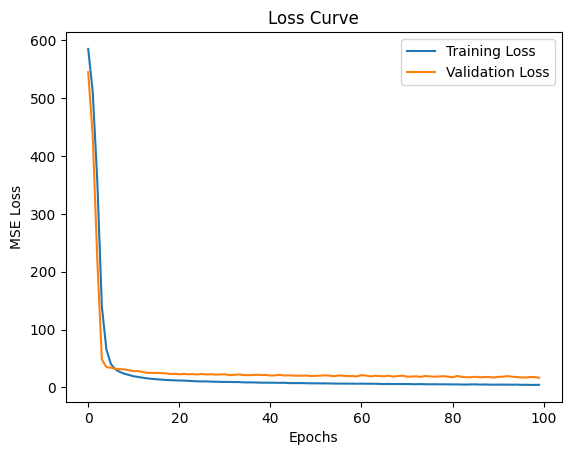

In [98]:
# plot training loss.

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

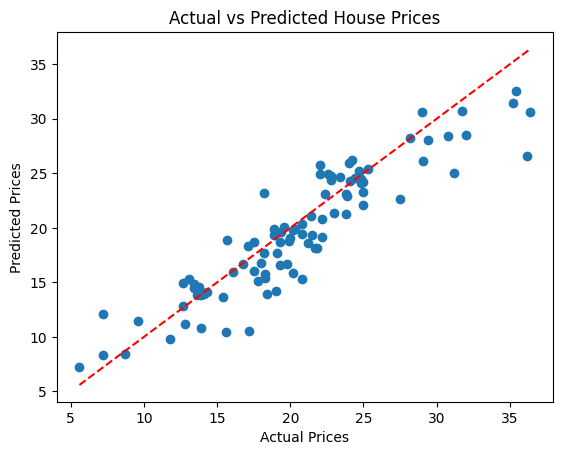

In [123]:
# actual Vs predicted plot.

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.title("Actual vs Predicted House Prices")
plt.show()